In [1]:
import sys 
sys.path.append("..")

from src.project.train import train_and_evaluate
from src.project.main import fit_transform
from src.project.features import features

In [2]:
data = fit_transform(None)

In [3]:
data.head()

,store,date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,month,season,...,temp_x_season,holiday_x_fuel_price,holiday_x_temperature,total_holidays,weekly_sales_diff,weekly_sales_pct_change,weekly_sales_rolling_mean_2,weekly_sales_rolling_std_2,weekly_sales_rolling_mean_4,weekly_sales_rolling_std_4
0,1,2010-02-05,1643690.90,0.0,42.31,2.572,211.096358,8.106,2.0,Winter,...,0.000000,0.000,0.000000,1,-53538.68,-0.031545,1643690.900,0.000000,1.643691e+06,0.000000
1,1,2010-02-12,1641957.44,1.0,38.51,2.548,211.242170,8.106,2.0,Winter,...,0.000000,2.548,3.616667,1,47018.55,0.029480,1642824.170,1225.741321,1.642824e+06,1225.741321
2,1,2010-02-19,1611968.17,0.0,39.93,2.514,211.289143,8.106,2.0,Winter,...,0.000000,0.000,0.000000,1,72484.47,0.047084,1626962.805,21205.616180,1.632539e+06,17835.791719
3,1,2010-02-26,1409727.59,0.0,46.63,2.561,211.319643,8.106,2.0,Winter,...,0.000000,0.000,0.000000,0,-623593.07,-0.306687,1510847.880,143005.685549,1.576836e+06,112353.415114
4,1,2010-03-05,1554806.68,0.0,46.50,2.625,211.350143,8.106,3.0,Spring,...,8.055556,0.000,0.000000,0,-88884.22,-0.054076,1482267.135,102586.408347,1.554615e+06,103135.002548


In [4]:
model = train_and_evaluate(data=data,features=features)

In [5]:
model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=150, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [6]:
import pandas as pd 
df_store1 = data[data['store'] == 1].copy()
test_start = '2012-09-01'
test_end = '2012-10-30'

sept_oct_2012_data = df_store1[(df_store1['date'] >= test_start) & (df_store1['date'] <= test_end)]

data_wo_sept_oct2012 = df_store1[(df_store1['date'] < test_start) | (df_store1['date'] > test_end)]


Performance prédiction sur septembre octobre 2012 (exclu du training) :
RMSE : 46384.72
R2 : 0.643


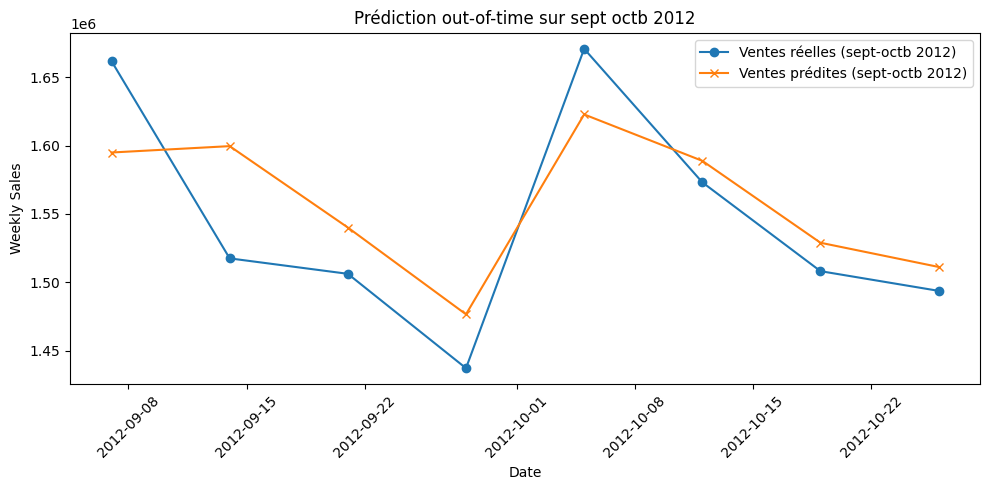

In [8]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt 
import numpy as np 
X_sept_oct_2012 = sept_oct_2012_data[features]
y_sept_oct_2012_true = sept_oct_2012_data['Weekly_Sales']

y_sept_oct_2012_pred = model.predict(X_sept_oct_2012)

print(f"\nPerformance prédiction sur septembre octobre 2012 (exclu du training) :")
print(f"RMSE : {np.sqrt(mean_squared_error(y_sept_oct_2012_true, y_sept_oct_2012_pred)):.2f}")
print(f"R2 : {r2_score(y_sept_oct_2012_true, y_sept_oct_2012_pred):.3f}")

plt.figure(figsize=(10,5))
plt.plot(sept_oct_2012_data['date'], y_sept_oct_2012_true, label='Ventes réelles (sept-octb 2012)', marker='o')
plt.plot(sept_oct_2012_data['date'], y_sept_oct_2012_pred, label='Ventes prédites (sept-octb 2012)', marker='x')
plt.title('Prédiction out-of-time sur sept octb 2012')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()